# The Nuclear Shell Model: Determination of spin and parity of nuclei

This notebook provides a hands-on tool to explore the predictions of the nuclear shell model and **compare them directly with experimental data**. This allows us to see where this simple model works well and where it breaks down, offering insight into the more complex nature of the nucleus.

### The Physics Behind It

The notebook is based on the single-particle shell model, as presented in Chapter 9 of Terranova's "A Modern Primer in Particle & Nuclear Physics". This model treats protons and neutrons (nucleons) as independent particles moving in an effective mean potential created by all the other nucleons. Much like electrons in an atom, these nucleons can only occupy discrete quantum energy levels. The nucleons fill these levels starting from the **lowest energy level at the bottom** and moving upwards.

1.  **Energy Levels:** The available levels are derived from a quantum mechanical potential (like Saxon-Woods) with a strong **spin-orbit interaction**. This interaction splits levels with orbital angular momentum `l > 0` into two new levels with total angular momentum `j = l + 1/2` and `j = l - 1/2`. The diagram below shows this level ordering, starting with the `1s₁/₂` state at the lowest energy.

2.  **Pauli Exclusion Principle:** Since protons and neutrons are fermions, only one can occupy each unique quantum state. A level with total angular momentum `j` can hold `2j + 1` identical nucleons. Nucleons fill up the lowest available energy states first.

3.  **Ground State Prediction:** The model's key predictive power comes from the **last unpaired nucleon(s)** in the highest occupied energy level.
    *   **Even-Even Nuclei:** All nucleons are paired up to a total angular momentum of 0. The model predicts a ground state of `0⁺`.
    *   **Odd-A Nuclei:** A single unpaired proton or neutron determines the nucleus's properties. The nuclear spin `I` is the nucleon's total angular momentum `j`, and the parity `P` is given by `(-1)^l`.
    *   **Odd-Odd Nuclei:** The total spin `I` is a combination of the two unpaired nucleons' spins (`|j_p - j_n| ≤ I ≤ j_p + j_n`), and the parity is the product of their individual parities, `P = (-1)^(lp + ln)`. The model only gives a range of possible spins.

### Comparing Theory with Reality

To test these predictions, this notebook downloads and reads data from the **NuBase2020 database** (`nubase_4.mas20.txt`), which is the standard experimental compilation of nuclear properties.

*   The code finds the experimental ground state spin and parity for the selected nucleus.
*   It then compares this real-world value to the simple shell model prediction.
*   The result is displayed as a **✅ Match!** or a **❌ Mismatch!**.

### How to Use This Tool

**Go to the final code cell at the bottom of the notebook.** Change the values for `Z_input` and `N_input` to the desired number of protons and neutrons, and then run that cell.

The output will now show:
1.  The level-filling diagram.
2.  The shell model's prediction for `I^P`.
3.  The experimentally measured value of `I^P` from NuDat3.
4.  A clear statement on whether the prediction **matches** or **mismatches** the data.

**Try some examples:**
*   **A good match:** Oxygen-17 (`Z=8`, `N=9`). The prediction should match the data perfectly.
*   **A classic mismatch:** Fluorine-19 (`Z=9`, `N=10`). Why do you think the model fails here? (Hint: The simple model ignores residual interactions between nucleons that can favor certain configurations or even reorder closely spaced levels).
*   **An odd-odd case:** Nitrogen-14 (`Z=7`, `N=7`). Does the experimental spin fall within the predicted range?

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
import pandas as pd

# --- DATA LOADING FOR NUDAT3 (Unchanged) ---
def load_nudat_data():
    """Loads the local NuBase2020 data file into a pandas DataFrame."""
    filename = 'nubase_4.mas20.txt'
    if not os.path.exists(filename):
        print(f"ERROR: Data file '{filename}' not found.")
        return None

    colspecs = [(0, 3), (4, 8), (11, 17), (88, 102)]
    names = ['A_str', 'ZZZi_str', 'IsotopeName', 'SpinParity']
    try:
        df_raw = pd.read_fwf(filename, colspecs=colspecs, names=names, header=17, dtype=str)
        
        df_raw['Z'] = pd.to_numeric(df_raw['ZZZi_str'].str[:-1], errors='coerce')
        df_raw['isomer_flag'] = pd.to_numeric(df_raw['ZZZi_str'].str[-1], errors='coerce')
        df_raw['A'] = pd.to_numeric(df_raw['A_str'], errors='coerce')
        df_raw.dropna(subset=['A', 'Z', 'isomer_flag'], inplace=True)
        df_raw['N'] = df_raw['A'].astype(int) - df_raw['Z'].astype(int)
        
        df_ground_states = df_raw[df_raw['isomer_flag'] == 0].copy()
        
        df_ground_states['N'] = df_ground_states['N'].astype(int)
        df_ground_states['Z'] = df_ground_states['Z'].astype(int)
        df_ground_states['A'] = df_ground_states['A'].astype(int)

        df_ground_states['SpinParity'] = df_ground_states['SpinParity'].str.split().str[0]
        df_ground_states['IsotopeName'] = df_ground_states['IsotopeName'].str.strip()
        
        print("NuDat3 data loaded successfully from local file.")
        return df_ground_states[['N', 'Z', 'A', 'IsotopeName', 'SpinParity']]
    
    except Exception as e:
        print(f"An unexpected error occurred during parsing: {e}")
        return None

nudat_df = load_nudat_data()


# --- SHELL MODEL DEFINITIONS AND FUNCTIONS ---
# **** UPDATED SHELL ORDERING ****
# Based on the experimentally confirmed level scheme from the provided Springer link.
# Magic Numbers: 2, 8, 20, 28, 50, 82, 126, 184
shells = [
    # Shell 1 (Magic Number 2)
    [{'name': '1s$_{1/2}$', 'l': 0, 'j': 0.5, 'capacity': 2}],
    # Shell 2 (Magic Number 8)
    [{'name': '1p$_{3/2}$', 'l': 1, 'j': 1.5, 'capacity': 4},
     {'name': '1p$_{1/2}$', 'l': 1, 'j': 0.5, 'capacity': 2}],
    # Shell 3 (Magic Number 20)
    [{'name': '1d$_{5/2}$', 'l': 2, 'j': 2.5, 'capacity': 6},
     {'name': '2s$_{1/2}$', 'l': 0, 'j': 0.5, 'capacity': 2},
     {'name': '1d$_{3/2}$', 'l': 2, 'j': 1.5, 'capacity': 4}],
    # Shell 4 (Magic Number 28)
    [{'name': '1f$_{7/2}$', 'l': 3, 'j': 3.5, 'capacity': 8}],
    # Shell 5 (Magic Number 50)
    [{'name': '2p$_{3/2}$', 'l': 1, 'j': 1.5, 'capacity': 4},
     {'name': '1f$_{5/2}$', 'l': 3, 'j': 2.5, 'capacity': 6},
     {'name': '2p$_{1/2}$', 'l': 1, 'j': 0.5, 'capacity': 2},
     {'name': '1g$_{9/2}$', 'l': 4, 'j': 4.5, 'capacity': 10}],
    # Shell 6 (Magic Number 82)
    [{'name': '1g$_{7/2}$', 'l': 4, 'j': 3.5, 'capacity': 8},
     {'name': '2d$_{5/2}$', 'l': 2, 'j': 2.5, 'capacity': 6},
     {'name': '3s$_{1/2}$', 'l': 0, 'j': 0.5, 'capacity': 2},
     {'name': '1h$_{11/2}$', 'l': 5, 'j': 5.5, 'capacity': 12},
     {'name': '2d$_{3/2}$', 'l': 2, 'j': 1.5, 'capacity': 4}],
    # Shell 7 (Magic Number 126 for neutrons)
    [{'name': '2f$_{7/2}$', 'l': 3, 'j': 3.5, 'capacity': 8},
     {'name': '1h$_{9/2}$', 'l': 5, 'j': 4.5, 'capacity': 10},
     {'name': '3p$_{3/2}$', 'l': 1, 'j': 1.5, 'capacity': 4},
     {'name': '2f$_{5/2}$', 'l': 3, 'j': 2.5, 'capacity': 6},
     {'name': '3p$_{1/2}$', 'l': 1, 'j': 0.5, 'capacity': 2},
     {'name': '1i$_{13/2}$', 'l': 6, 'j': 6.5, 'capacity': 14}],
    # Shell 8 (Magic Number 184 for neutrons)
    [{'name': '2g$_{9/2}$', 'l': 4, 'j': 4.5, 'capacity': 10},
     {'name': '1i$_{11/2}$', 'l': 6, 'j': 5.5, 'capacity': 12},
     {'name': '1j$_{15/2}$', 'l': 7, 'j': 7.5, 'capacity': 16}]
]
flat_levels = [level for shell in shells for level in shell]

def get_parity_symbol(l): return '+' if (-1)**l > 0 else '-'
def format_spin(j): return f"{int(2*j)}/2"

def fill_levels(num_nucleons):
    remaining, filling, last_unpaired_level = num_nucleons, {}, None
    for level in flat_levels:
        if remaining > 0:
            fill_count = min(remaining, level['capacity'])
            filling[level['name']] = fill_count
            if fill_count % 2 != 0:
                last_unpaired_level = level.copy()
            remaining -= fill_count
        else: filling[level['name']] = 0
    return filling, last_unpaired_level

# --- The rest of the functions are unchanged ---
def predict_spin_parity(Z, N, last_proton_level, last_neutron_level):
    is_Z_even, is_N_even = (Z % 2 == 0), (N % 2 == 0)
    
    if is_Z_even and is_N_even:
        return ("Even-Even", "0+", 0.0, '+', [])
    
    elif not is_Z_even and is_N_even: # Odd-Proton
        if not last_proton_level: return ("Odd-A", "N/A", None, None, [])
        j, l = last_proton_level['j'], last_proton_level['l']
        parity = get_parity_symbol(l)
        spin_str = format_spin(j)
        return ("Odd-A", f"({spin_str}){parity}", j, parity, [])
        
    elif is_Z_even and not is_N_even: # Odd-Neutron
        if not last_neutron_level: return ("Odd-A", "N/A", None, None, [])
        j, l = last_neutron_level['j'], last_neutron_level['l']
        parity = get_parity_symbol(l)
        spin_str = format_spin(j)
        return ("Odd-A", f"({spin_str}){parity}", j, parity, [])
        
    else: # Odd-Odd
        if not last_proton_level or not last_neutron_level: return ("Odd-Odd", "N/A", None, None, [])
        jp, lp = last_proton_level['j'], last_proton_level['l']
        jn, ln = last_neutron_level['j'], last_neutron_level['l']
        
        total_parity = get_parity_symbol(lp + ln)
        min_I, max_I = abs(jp - jn), jp + jn
        possible_spins = [int(i) for i in np.arange(min_I, max_I + 1)]
        spin_range_str = f"[{', '.join(map(str, possible_spins))}]"
        
        return ("Odd-Odd", f"{spin_range_str}{total_parity}", None, total_parity, possible_spins)

def get_experimental_data(Z, N, df):
    if df is None: return "Data not available", "Unknown"
    record = df[(df['Z'] == Z) & (df['N'] == N)]
    if record.empty:
        return "No data", f"A={Z+N}, Z={Z}"
    
    spin_parity = "No data" if pd.isna(record['SpinParity'].iloc[0]) else record['SpinParity'].iloc[0]
    isotope_name = "Unknown" if pd.isna(record['IsotopeName'].iloc[0]) else record['IsotopeName'].iloc[0]
    return spin_parity, isotope_name

def parse_and_compare(pred_tuple, exp_str):
    if exp_str == "No data" or exp_str == "Data not available":
        return "🟡 Cannot compare (no experimental data)."
    exp_str_clean = exp_str.replace('(', '').replace(')', '').replace('*','')
    exp_parity = exp_str_clean[-1]
    exp_spin_str = exp_str_clean[:-1]
    try:
        if "/" in exp_spin_str:
            num, den = map(int, exp_spin_str.split('/'))
            exp_j = float(num) / den
        else: exp_j = int(exp_spin_str)
    except (ValueError, IndexError): return f"🟡 Cannot parse experimental value: {exp_str}"
    
    nuc_type, pred_str, pred_j, pred_parity, pred_spin_range = pred_tuple
    
    if nuc_type == "Even-Even": match = (exp_j == 0 and exp_parity == '+')
    elif nuc_type == "Odd-A": match = (pred_j is not None and np.isclose(exp_j, pred_j) and exp_parity == pred_parity)
    elif nuc_type == "Odd-Odd": match = (exp_j in pred_spin_range and exp_parity == pred_parity)
    else: return "Model prediction failed."
        
    return "✅ Match!" if match else "❌ Mismatch!"

def plot_levels(Z, N, proton_fill, neutron_fill, isotope_name):
    fig, ax = plt.subplots(figsize=(8, 12)); y_pos = 0; y_ticks = []; y_labels = []
    for shell in shells:
        for level in shell:
            y_pos += 2; y_ticks.append(y_pos); y_labels.append(level['name'])
            ax.hlines(y_pos, -1.5, 1.5, colors='gray', lw=1)
            capacity = level['capacity']
            p_occ = proton_fill.get(level['name'], 0)
            n_occ = neutron_fill.get(level['name'], 0)
            for i in range(capacity):
                ax.plot(-0.5 - i * 0.1, y_pos, 'o', ms=8, mec='black', mfc='black' if i < p_occ else 'white')
                ax.plot(0.5 + i * 0.1, y_pos, 'o', ms=8, mec='black', mfc='black' if i < n_occ else 'white')
        y_pos += 1
    ax.set_yticks(y_ticks); ax.set_yticklabels(y_labels)
    ax.set_ylim(0, y_pos + 1); ax.set_xlim(-2.5, 2.5)
    ax.set_xticks([-1, 1]); ax.set_xticklabels(['Protons (Z)', 'Neutrons (N)'], fontsize=14)
    ax.tick_params(axis='x', length=0)
    
    title_name = f"$^{{{Z+N}}}${isotope_name.lstrip('0123456789')}"
    ax.set_title(f"Shell Model Filling for {title_name}", fontsize=16)
    
    ax.axvline(0, color='black', lw=0.8); plt.show()

def run_shell_model_explorer(Z, N):
    if not isinstance(Z, int) or not isinstance(N, int) or Z < 0 or N < 0:
        print("Error: Please provide non-negative integers for Z and N."); return
    if Z == 0 and N == 0: print("Please select at least one proton or neutron."); return
        
    proton_fill, last_proton_level = fill_levels(Z)
    neutron_fill, last_neutron_level = fill_levels(N)
    
    prediction_tuple = predict_spin_parity(Z, N, last_proton_level, last_neutron_level)
    experimental_data, isotope_name = get_experimental_data(Z, N, nudat_df)
    comparison_result = parse_and_compare(prediction_tuple, experimental_data)
    
    title_name = f"$^{{{Z+N}}}${isotope_name.lstrip('0123456789')}"
    print(f"Nucleus: {title_name} (Z={Z}, N={N})")
    print("-" * 50)
    print(f"Shell Model Prediction: {prediction_tuple[1]}")
    print(f"Experimental Value (NuDat3): {experimental_data}")
    print(f"Comparison: {comparison_result}")
    
    plot_levels(Z, N, proton_fill, neutron_fill, isotope_name)

NuDat3 data loaded successfully from local file.


Nucleus: $^{210}$Po (Z=84, N=126)
--------------------------------------------------
Shell Model Prediction: 0+
Experimental Value (NuDat3): 0+
Comparison: ✅ Match!


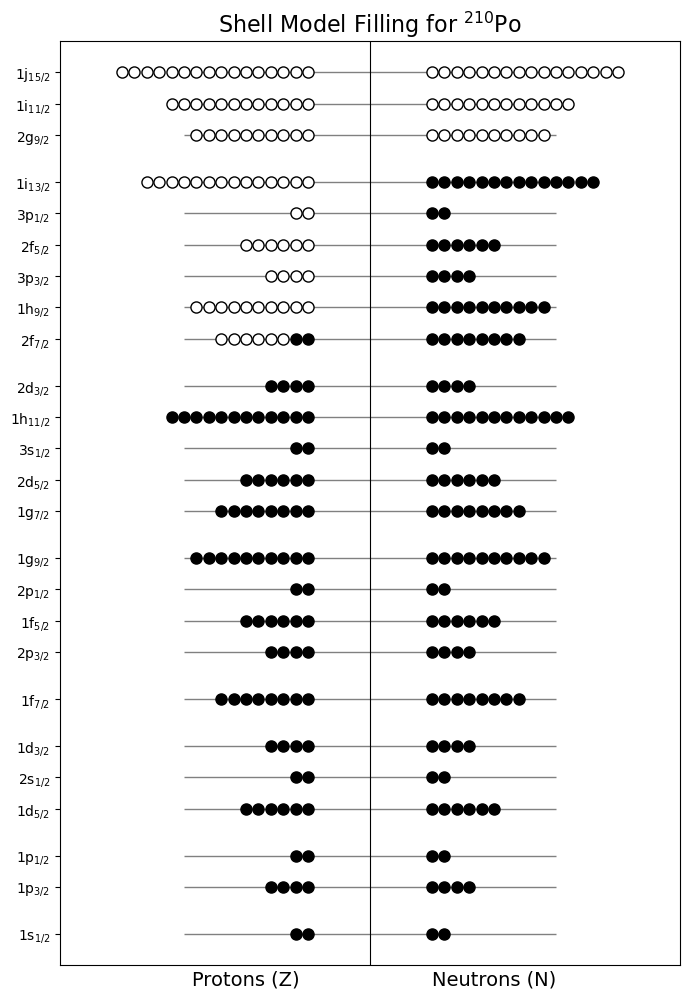

In [12]:
# --- USER INPUT ---
# Change these values and re-run this cell to see the diagram for a different nucleus.

Z_input = 84
A_input = 210
N_input = A_input - Z_input
#Note: the order of single particle levels may vary

# --- EXECUTION ---
run_shell_model_explorer(Z_input, N_input)